# Ćwiczenie 7 - Sieci Rekurencyjne (RNN/LSTM)

W tym ćwiczeniu wykorzystamy sieci rekurencyjne do klasyfikacji sentymentu recenzji filmowych ze zbioru IMDB.

**Cel:** Przebadać wpływ różnych parametrów sieci rekurencyjnych:
- Typ warstwy rekurencyjnej (RNN vs LSTM)
- Wymiar warstwy rekurencyjnej (hidden_size)
- Wpływ przycinania sekwencji do różnych długości (max vs 10, 20, 50, 100, 200 słów)

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import Counter
import re
import html

# Sprawdź czy GPU jest dostępne
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(torch.version.cuda)
print(torch.cuda.is_available()) 
print(torch.cuda.get_device_name(0))  

Using device: cuda
11.8
True
NVIDIA GeForce GTX 1080


## Ładowanie danych IMDB

Używamy zbioru recenzji filmów IMDB dostępnego w Keras. Zbiór zawiera 25,000 recenzji treningowych i 25,000 testowych, z etykietami 0 (negatywna) lub 1 (pozytywna).

In [2]:
from tensorflow.keras.datasets import imdb

# Maksymalna liczba słów w słowniku
VOCAB_SIZE = 10000

# Załaduj dane
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=VOCAB_SIZE)

# Załaduj słownik słów (indeks -> słowo)
word_index = imdb.get_word_index()
reverse_word_index = {v + 3: k for k, v in word_index.items()}
reverse_word_index[0] = '<PAD>'
reverse_word_index[1] = '<START>'
reverse_word_index[2] = '<UNK>'
reverse_word_index[3] = '<UNUSED>'

print(f"Liczba przykładów treningowych: {len(train_data)}")
print(f"Liczba przykładów testowych: {len(test_data)}")
print(f"Rozmiar słownika: {VOCAB_SIZE}")

Liczba przykładów treningowych: 25000
Liczba przykładów testowych: 25000
Rozmiar słownika: 10000


## Eksploracja danych - próbki i statystyki

In [3]:
def decode_review(encoded_review):
    """Dekoduje zakodowaną recenzję do tekstu."""
    return ' '.join([reverse_word_index.get(i, '<?>') for i in encoded_review])

# Pokaż przykładowe recenzje
print("=" * 80)
print("PRZYKŁADOWE RECENZJE")
print("=" * 80)

for i in range(3):
    print(f"\n--- Recenzja {i+1} (label: {'pozytywna' if train_labels[i] == 1 else 'negatywna'}) ---")
    decoded = decode_review(train_data[i])
    print(f"Długość: {len(train_data[i])} słów")
    print(f"Tekst (pierwsze 200 znaków): {decoded[:200]}...")

PRZYKŁADOWE RECENZJE

--- Recenzja 1 (label: pozytywna) ---
Długość: 218 słów
Tekst (pierwsze 200 znaków): <START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and ...

--- Recenzja 2 (label: negatywna) ---
Długość: 189 słów
Tekst (pierwsze 200 znaków): <START> big hair big boobs bad music and a giant safety pin these are the words to best describe this terrible movie i love cheesy horror movies and i've seen hundreds but this had got to be on of the...

--- Recenzja 3 (label: negatywna) ---
Długość: 141 słów
Tekst (pierwsze 200 znaków): <START> this has to be one of the worst films of the 1990s when my friends i were watching this film being the target audience it was aimed at we just sat watched the first half an hour with our jaws ...



STATYSTYKI DŁUGOŚCI SEKWENCJI

Dane treningowe:
  Min: 11, Max: 2494
  Średnia: 238.7, Mediana: 178.0
  Odchylenie std: 176.5

Percentyle długości:
  50%: 178 słów
  75%: 291 słów
  90%: 467 słów
  95%: 610 słów
  99%: 926 słów


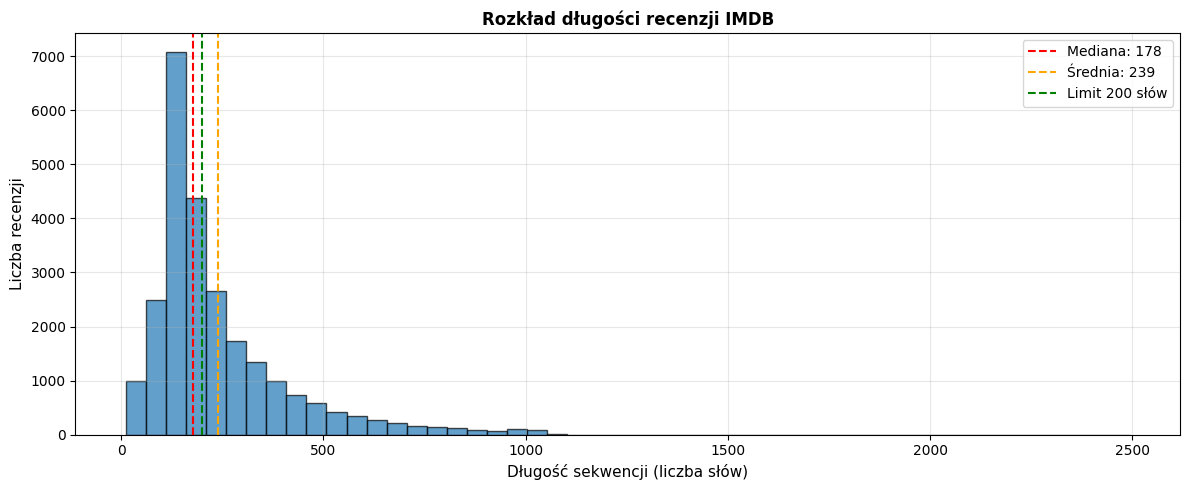


Pokrycie przy różnych limitach długości:
  Do 50 słów: 2.1% recenzji mieści się w całości
  Do 100 słów: 11.3% recenzji mieści się w całości
  Do 200 słów: 57.3% recenzji mieści się w całości
  Do 300 słów: 76.4% recenzji mieści się w całości
  Do 500 słów: 91.6% recenzji mieści się w całości


In [4]:
# Statystyki długości sekwencji
train_lengths = [len(seq) for seq in train_data]
test_lengths = [len(seq) for seq in test_data]

print("\n" + "=" * 80)
print("STATYSTYKI DŁUGOŚCI SEKWENCJI")
print("=" * 80)
print(f"\nDane treningowe:")
print(f"  Min: {min(train_lengths)}, Max: {max(train_lengths)}")
print(f"  Średnia: {np.mean(train_lengths):.1f}, Mediana: {np.median(train_lengths):.1f}")
print(f"  Odchylenie std: {np.std(train_lengths):.1f}")

# Percentyle
percentiles = [50, 75, 90, 95, 99]
print(f"\nPercentyle długości:")
for p in percentiles:
    val = np.percentile(train_lengths, p)
    print(f"  {p}%: {val:.0f} słów")

# Histogram długości
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(train_lengths, bins=50, edgecolor='black', alpha=0.7)
ax.axvline(np.median(train_lengths), color='red', linestyle='--', label=f'Mediana: {np.median(train_lengths):.0f}')
ax.axvline(np.mean(train_lengths), color='orange', linestyle='--', label=f'Średnia: {np.mean(train_lengths):.0f}')
ax.axvline(200, color='green', linestyle='--', label='Limit 200 słów')
ax.set_xlabel('Długość sekwencji (liczba słów)', fontsize=11)
ax.set_ylabel('Liczba recenzji', fontsize=11)
ax.set_title('Rozkład długości recenzji IMDB', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Ile recenzji zmieści się w różnych limitach?
print(f"\nPokrycie przy różnych limitach długości:")
for limit in [50, 100, 200, 300, 500]:
    coverage = sum(1 for l in train_lengths if l <= limit) / len(train_lengths) * 100
    print(f"  Do {limit} słów: {coverage:.1f}% recenzji mieści się w całości")

## Analiza - czy potrzebne jest czyszczenie?

Dane z Keras są już wstępnie przetworzone (lowercase, tokenizacja). Sprawdźmy jednak jak wyglądają oryginalne dane.

In [5]:
# Sprawdź czy są tagi HTML, specjalne znaki, itp.
print("=" * 80)
print("ANALIZA ZAWARTOŚCI SŁOWNIKA")
print("=" * 80)

# Pokaż niektóre słowa ze słownika
print("\nPrzykładowe słowa ze słownika (id 100-120):")
for i in range(100, 120):
    word = reverse_word_index.get(i, '<N/A>')
    print(f"  {i}: '{word}'")

# Sprawdź czy są tagi HTML-owe
html_like_words = []
for idx, word in reverse_word_index.items():
    if '<' in word or '>' in word or 'br' == word:
        html_like_words.append((idx, word))

print(f"\nSłowa podobne do tagów HTML: {html_like_words[:20]}")

# Analiza - jakie tokeny specjalne występują?
special_tokens = []
for idx, word in reverse_word_index.items():
    if not word.isalpha() and word not in ['<PAD>', '<START>', '<UNK>', '<UNUSED>']:
        special_tokens.append((idx, word))

print(f"\nTokeny niealfabetyczne (pierwsze 30): {special_tokens[:30]}")

ANALIZA ZAWARTOŚCI SŁOWNIKA

Przykładowe słowa ze słownika (id 100-120):
  100: 'could'
  101: 'any'
  102: 'movies'
  103: 'after'
  104: 'think'
  105: 'characters'
  106: 'watch'
  107: 'two'
  108: 'films'
  109: 'character'
  110: 'seen'
  111: 'many'
  112: 'being'
  113: 'life'
  114: 'plot'
  115: 'never'
  116: 'acting'
  117: 'little'
  118: 'best'
  119: 'love'

Słowa podobne do tagów HTML: [(10, 'br'), (0, '<PAD>'), (1, '<START>'), (2, '<UNK>'), (3, '<UNUSED>')]

Tokeny niealfabetyczne (pierwsze 30): [(52012, "hold's"), (52013, "'royale"), (40834, "harpo's"), (52016, "diplomat's"), (52019, "spider'"), (52020, "wood'"), (34705, "hangin'"), (52022, "'prix"), (52024, "tart'n'tangy"), (11041, "tom's"), (40838, '272'), (52031, '273'), (34709, '275'), (52034, "yomada's"), (34710, "madman's"), (26341, "kid'"), (30572, "'girlfriend'"), (52038, "'pleasure"), (52039, "'reloaded'"), (40842, "kazakos'"), (52042, "tom''"), (40843, "noe's"), (52044, "error'"), (52047, "eggar's"), (52049,

In [6]:
# Sprawdźmy pełną recenzję zdekodowaną
print("=" * 80)
print("PEŁNA PRZYKŁADOWA RECENZJA (zdekodowana)")
print("=" * 80)
full_review = decode_review(train_data[0])
print(f"\nLabel: {'pozytywna' if train_labels[0] == 1 else 'negatywna'}")
print(f"Długość: {len(train_data[0])} słów\n")
print(full_review)

PEŁNA PRZYKŁADOWA RECENZJA (zdekodowana)

Label: pozytywna
Długość: 218 słów

<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <UNK> to the two little boy's that played the <UNK> of norman and paul they were just brilliant children are often left out of the <UNK> list i think because the stars that play them all grown up are such a big profile f

**Wnioski z eksploracji danych:**

Dane IMDB z Keras są już przetworzone:
- Wszystko jest lowercase
- Tokeny numeryczne (indeksy słów)
- Słowo 'br' to pozostałość po tagu `<br>` z HTML
- Niektóre znaki specjalne (np. `'s`, `'t`) są zachowane jako osobne tokeny

**Dla naszych eksperymentów:**
- Nie musimy czyścić danych - są już przetworzone
- Możemy jednak zbadać wpływ usunięcia tokenu 'br' (tag HTML)
- Głównym przedmiotem badań będzie długość sekwencji

## Definicja modeli RNN i LSTM

In [7]:
class SentimentRNN(nn.Module):
    """
    Ulepszony model do analizy sentymentu.
    Zmiany: Obsługa Bidirectional (dwukierunkowość) i lepsze zarządzanie stanami ukrytymi.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, 
                 rnn_type='LSTM', num_layers=2, bidirectional=True, dropout=0.5):
        super(SentimentRNN, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn_type = rnn_type
        self.bidirectional = bidirectional
        
        # Obliczamy wymiar wejścia do warstwy liniowej
        # Jeśli sieć jest dwukierunkowa, wyjście jest 2x większe
        fc_input_dim = hidden_dim * 2 if bidirectional else hidden_dim
        
        if rnn_type == 'LSTM':
            self.rnn = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                              batch_first=True, bidirectional=bidirectional,
                              dropout=dropout if num_layers > 1 else 0)
        else:  # RNN
            self.rnn = nn.RNN(embed_dim, hidden_dim, num_layers=num_layers,
                             batch_first=True, bidirectional=bidirectional,
                             dropout=dropout if num_layers > 1 else 0,
                             nonlinearity='tanh')
        
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(fc_input_dim, output_dim)
        
    def forward(self, x):
        # x: (batch_size, seq_len)
        embedded = self.dropout(self.embedding(x)) 
        
        if self.rnn_type == 'LSTM':
            output, (hidden, cell) = self.rnn(embedded)
        else:
            output, hidden = self.rnn(embedded)
        
        if self.bidirectional:
            # Bierzemy ostatni stan z warstwy forward i ostatni z backward i sklejamy je
            # hidden shape: [num_layers * num_directions, batch, hidden_dim]
            hidden = self.dropout(torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1))
        else:
            hidden = self.dropout(hidden[-1,:,:])
            
        out = self.fc(hidden)
        return out

## Przygotowanie danych - Dataset i DataLoader

In [8]:
class IMDBDataset(Dataset):
    """
    Dataset dla recenzji IMDB.
    """
    def __init__(self, sequences, labels, max_len=None):
        self.labels = torch.tensor(labels, dtype=torch.float32)
        
        # Przytnij lub zachowaj oryginalną długość
        if max_len is not None:
            self.sequences = [torch.tensor(seq[:max_len], dtype=torch.long) for seq in sequences]
        else:
            self.sequences = [torch.tensor(seq, dtype=torch.long) for seq in sequences]
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]


def collate_fn(batch):
    """
    Funkcja do padowania sekwencji w batchu do jednakowej długości.
    """
    sequences, labels = zip(*batch)
    # Pad sequences do długości najdłuższej w batchu
    sequences_padded = pad_sequence(sequences, batch_first=True, padding_value=0)
    labels = torch.stack(labels)
    return sequences_padded, labels


def create_data_loaders(train_data, train_labels, test_data, test_labels, 
                        max_len=None, batch_size=64, subset_size=None):
    """
    Tworzy DataLoadery dla danych treningowych i testowych.
    """
    # Opcjonalnie użyj podzbioru danych
    if subset_size is not None:
        indices = np.random.choice(len(train_data), subset_size, replace=False)
        train_data = [train_data[i] for i in indices]
        train_labels = [train_labels[i] for i in indices]
    
    train_dataset = IMDBDataset(train_data, train_labels, max_len=max_len)
    test_dataset = IMDBDataset(test_data, test_labels, max_len=max_len)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, 
                             shuffle=True, collate_fn=collate_fn)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, 
                            shuffle=False, collate_fn=collate_fn)
    
    return train_loader, test_loader

## Funkcje pomocnicze

In [9]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """
    Trenuje model przez jedną epokę.
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs).squeeze(1)
        loss = criterion(outputs, labels)
        
        loss.backward()
        # Gradient clipping dla stabilności RNN
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        running_loss += loss.item()
        predicted = (torch.sigmoid(outputs) > 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc


def evaluate(model, test_loader, criterion, device):
    """
    Ewaluuje model na zbiorze testowym.
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs).squeeze(1)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(test_loader)
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc


def train_and_evaluate(model, train_loader, test_loader, epochs=10, lr=0.001):
    """
    Trenuje i ewaluuje model.
    """
    model = model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    history = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': []
    }
    
    for epoch in tqdm(range(epochs), desc="Training"):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        
        if (epoch + 1) % 5 == 0:
            tqdm.write(f"Epoch {epoch+1}/{epochs} - "
                      f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} - "
                      f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")
    
    return history, model


def plot_comparison(results_list, title):
    """
    Rysuje wykresy porównawcze dla różnych konfiguracji.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Wykres train loss
    for result in results_list:
        ax1.plot(result['history']['train_loss'], label=result['label'], linewidth=2)
    
    ax1.set_xlabel('Epoch', fontsize=11)
    ax1.set_ylabel('Train Loss', fontsize=11)
    ax1.set_title('Training Loss Comparison', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)
    
    # Wykres test accuracy
    for result in results_list:
        ax2.plot(result['history']['test_acc'], label=result['label'], linewidth=2)
    
    ax2.set_xlabel('Epoch', fontsize=11)
    ax2.set_ylabel('Test Accuracy', fontsize=11)
    ax2.set_title('Test Accuracy Comparison', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)
    
    plt.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


def print_summary_table(results_list):
    """
    Wyświetla tabelę podsumowującą wyniki.
    """
    print("\n" + "="*90)
    print("PODSUMOWANIE WYNIKÓW")
    print("="*90)
    print(f"{'Konfiguracja':<45} {'Train Acc':>12} {'Test Acc':>12} {'Gap':>12}")
    print("-"*90)
    
    for result in results_list:
        train_acc = result['history']['train_acc'][-1]
        test_acc = result['history']['test_acc'][-1]
        gap = train_acc - test_acc
        print(f"{result['label']:<45} {train_acc:>12.4f} {test_acc:>12.4f} {gap:>12.4f}")
    
    print("="*90)

## Parametry bazowe

Definiujemy parametry, które będą stałe we wszystkich eksperymentach (o ile nie są przedmiotem badania).

In [10]:
# Parametry bazowe
EMBED_DIM = 100
HIDDEN_DIM = 256
OUTPUT_DIM = 1 
EPOCHS = 15         
BATCH_SIZE = 64      
LEARNING_RATE = 0.001

# Parametry strukturalne
NUM_LAYERS = 2      
BIDIRECTIONAL = True 
DROPOUT = 0.5 


TRAIN_SUBSET = 15000

print(f"Parametry ulepszone:")
print(f"  Embed dim: {EMBED_DIM}")
print(f"  Hidden dim: {HIDDEN_DIM}")
print(f"  Bidirectional: {BIDIRECTIONAL}")
print(f"  Train subset: {TRAIN_SUBSET}")

Parametry ulepszone:
  Embed dim: 100
  Hidden dim: 256
  Bidirectional: True
  Train subset: 15000


## Eksperyment 1: RNN vs LSTM

Porównamy podstawowy RNN z LSTM. LSTM powinien lepiej radzić sobie z długimi sekwencjami dzięki mechanizmowi bram (gates).


=== Eksperyment 1: RNN vs LSTM ===

--- Trenowanie modelu RNN ---


Training:  33%|███▎      | 5/15 [01:21<02:41, 16.13s/it]

Epoch 5/15 - Train Loss: 0.7021, Train Acc: 0.5017 - Test Loss: 0.6967, Test Acc: 0.5003


Training:  67%|██████▋   | 10/15 [02:41<01:19, 15.97s/it]

Epoch 10/15 - Train Loss: 0.7000, Train Acc: 0.5159 - Test Loss: 0.6879, Test Acc: 0.5486


...

Epoch 5/15 - Train Loss: 0.4968, Train Acc: 0.7690 - Test Loss: 0.4525, Test Acc: 0.8019


Training:  67%|██████▋   | 10/15 [05:06<02:31, 30.37s/it]

Epoch 10/15 - Train Loss: 0.3200, Train Acc: 0.8625 - Test Loss: 0.3691, Test Acc: 0.8456


Training: 100%|██████████| 15/15 [07:39<00:00, 30.64s/it]


Epoch 15/15 - Train Loss: 0.2323, Train Acc: 0.9085 - Test Loss: 0.3827, Test Acc: 0.8581


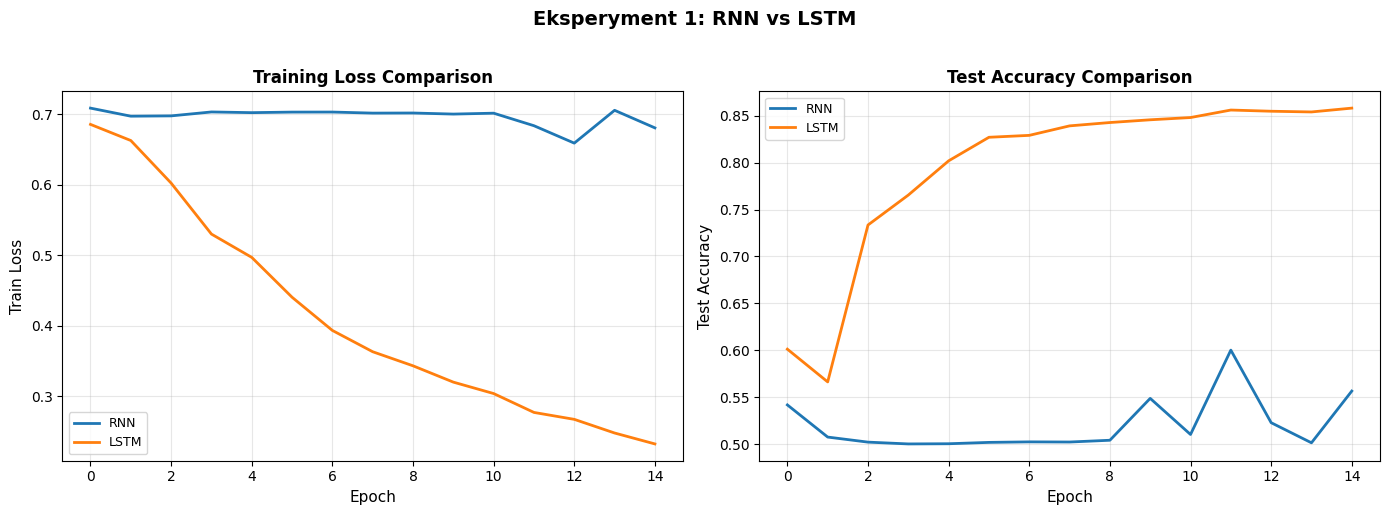


PODSUMOWANIE WYNIKÓW
Konfiguracja                                     Train Acc     Test Acc          Gap
------------------------------------------------------------------------------------------
RNN                                                 0.5737       0.5564       0.0172
LSTM                                                0.9085       0.8581       0.0504


In [11]:
print("\n=== Eksperyment 1: RNN vs LSTM ===")

results_rnn_type = []
rnn_types = ['RNN', 'LSTM']

MAX_LEN = 200 

for rnn_type in rnn_types:
    print(f"\n--- Trenowanie modelu {rnn_type} ---")
    
    train_loader, test_loader = create_data_loaders(
        train_data, train_labels, test_data, test_labels,
        max_len=MAX_LEN, batch_size=BATCH_SIZE, subset_size=TRAIN_SUBSET
    )
    

    model = SentimentRNN(
        vocab_size=VOCAB_SIZE,
        embed_dim=EMBED_DIM,
        hidden_dim=HIDDEN_DIM,
        output_dim=OUTPUT_DIM,
        rnn_type=rnn_type,
        num_layers=NUM_LAYERS,
        bidirectional=BIDIRECTIONAL,
        dropout=DROPOUT
    )
    
    # Trenuj
    history, trained_model = train_and_evaluate(
        model, train_loader, test_loader, epochs=EPOCHS, lr=LEARNING_RATE
    )
    
    results_rnn_type.append({
        'label': f'{rnn_type}',
        'history': history
    })

plot_comparison(results_rnn_type, "Eksperyment 1: RNN vs LSTM")
print_summary_table(results_rnn_type)

### Wnioski - Eksperyment 1:

**Porównanie RNN vs LSTM:**
- LSTM zazwyczaj osiąga lepsze wyniki dla dłuższych sekwencji
- Mechanizm bram (forget gate, input gate, output gate) pozwala LSTM na:
  - Lepsze zachowywanie informacji na długich dystansach
  - Unikanie problemu zanikającego gradientu (vanishing gradient)
- RNN może być szybszy w treningu, ale mniej skuteczny dla długich tekstów


## Eksperyment 2: Wymiar warstwy rekurencyjnej

Zbadamy wpływ rozmiaru warstwy ukrytej (hidden_dim) na jakość klasyfikacji.


=== Eksperyment 2: Wymiar warstwy rekurencyjnej ===

--- Trenowanie LSTM z hidden_dim=32 ---


Training:  33%|███▎      | 5/15 [00:21<00:43,  4.31s/it]

Epoch 5/15 - Train Loss: 0.5726, Train Acc: 0.7125 - Test Loss: 0.5485, Test Acc: 0.7308


Training:  67%|██████▋   | 10/15 [00:41<00:19,  3.97s/it]

Epoch 10/15 - Train Loss: 0.4133, Train Acc: 0.8241 - Test Loss: 0.4209, Test Acc: 0.8308


...

Epoch 5/15 - Train Loss: 0.6562, Train Acc: 0.6121 - Test Loss: 0.6762, Test Acc: 0.6206


Training:  67%|██████▋   | 10/15 [05:12<02:36, 31.26s/it]

Epoch 10/15 - Train Loss: 0.3508, Train Acc: 0.8493 - Test Loss: 0.4350, Test Acc: 0.8342


Training: 100%|██████████| 15/15 [07:42<00:00, 30.80s/it]


Epoch 15/15 - Train Loss: 0.2526, Train Acc: 0.8973 - Test Loss: 0.3759, Test Acc: 0.8558


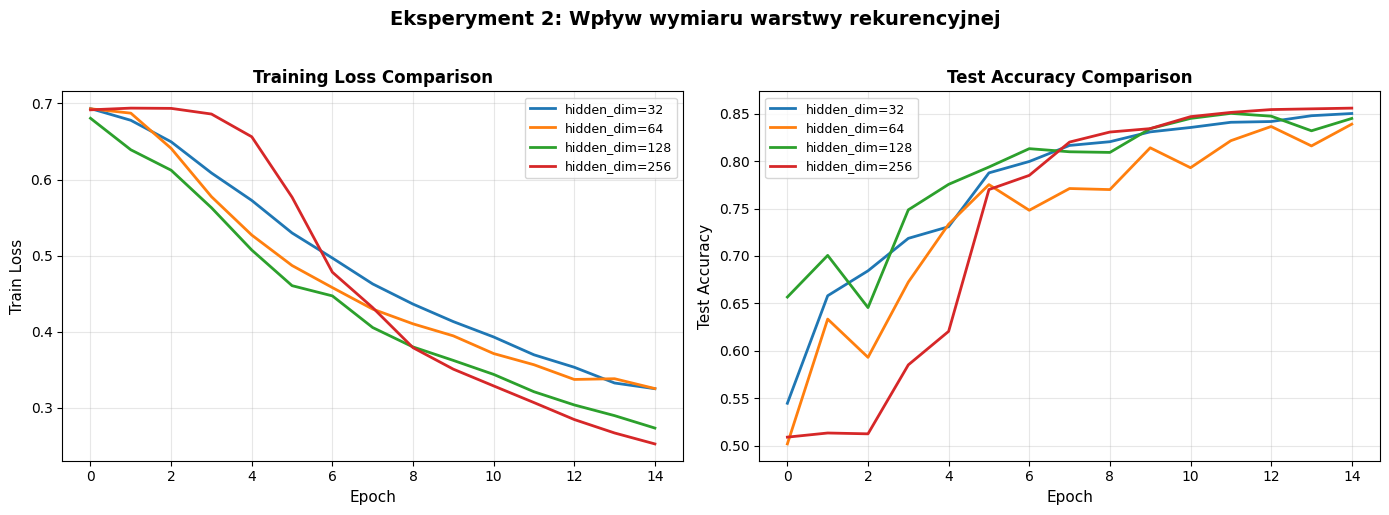


PODSUMOWANIE WYNIKÓW
Konfiguracja                                     Train Acc     Test Acc          Gap
------------------------------------------------------------------------------------------
hidden_dim=32                                       0.8668       0.8501       0.0167
hidden_dim=64                                       0.8665       0.8389       0.0276
hidden_dim=128                                      0.8883       0.8449       0.0433
hidden_dim=256                                      0.8973       0.8558       0.0415


In [12]:
print("\n=== Eksperyment 2: Wymiar warstwy rekurencyjnej ===")

results_hidden = []
hidden_dims = [32, 64, 128, 256]

for hidden_dim in hidden_dims:
    print(f"\n--- Trenowanie LSTM z hidden_dim={hidden_dim} ---")
    
    train_loader, test_loader = create_data_loaders(
        train_data, train_labels, test_data, test_labels,
        max_len=MAX_LEN, batch_size=BATCH_SIZE, subset_size=TRAIN_SUBSET
    )
    
    model = SentimentRNN(
        vocab_size=VOCAB_SIZE,
        embed_dim=EMBED_DIM,
        hidden_dim=hidden_dim,
        output_dim=OUTPUT_DIM,
        rnn_type='LSTM'
    )
    
    history, trained_model = train_and_evaluate(
        model, train_loader, test_loader, epochs=EPOCHS, lr=LEARNING_RATE
    )
    
    results_hidden.append({
        'label': f'hidden_dim={hidden_dim}',
        'history': history
    })

plot_comparison(results_hidden, "Eksperyment 2: Wpływ wymiaru warstwy rekurencyjnej")
print_summary_table(results_hidden)

### Wnioski - Eksperyment 2:

**Wpływ wymiaru warstwy ukrytej:**

Dla wszystkich rozmiarów warstwy ukrytej (32, 64, 128, 256) wyniki na zbiorze treningowym są zbliżone. Wraz ze wzrostem pojemności modelu zwiększa się jednak **gap między dokładnością treningową a testową** 

**Trade-off:**
- Czas treningu rośnie z rozmiarem warstwy
- Większa pojemność (hidden_dim) zwiększa luki w uogólnianiu
- Musimy znaleźć balans między pojemnością a generalizacją

## Eksperyment 3: Długość sekwencji 

To jest główny eksperyment z zadania. Zbadamy wpływ przycinania sekwencji do różnych długości:
- Bardzo krótkie: 10, 20 słów
- Średnie: 50, 100 słów  
- Długie: 200, 500 słów
- Maksymalna długość w batchu (dynamiczne padowanie)

In [ ]:
print("\n=== Eksperyment 3: Długość sekwencji ===")

results_seq_len = []
# None oznacza użycie pełnej długości 
seq_lengths = [10, 20, 50, 100, 200, 500, None]

for max_len in seq_lengths:
    label = f'max_len={max_len}' if max_len else 'max_len=full (dynamic)'
    print(f"\n--- Trenowanie LSTM z {label} ---")
    
    train_loader, test_loader = create_data_loaders(
        train_data, train_labels, test_data, test_labels,
        max_len=max_len, batch_size=BATCH_SIZE, subset_size=TRAIN_SUBSET
    )
    
    model = SentimentRNN(
        vocab_size=VOCAB_SIZE,
        embed_dim=EMBED_DIM,
        hidden_dim=HIDDEN_DIM,
        output_dim=OUTPUT_DIM,
        rnn_type='LSTM'
    )
    
    history, trained_model = train_and_evaluate(
        model, train_loader, test_loader, epochs=EPOCHS, lr=LEARNING_RATE
    )
    
    results_seq_len.append({
        'label': label,
        'history': history
    })

plot_comparison(results_seq_len, "Eksperyment 3: Wpływ długości sekwencji")
print_summary_table(results_seq_len)


=== Eksperyment 3: Długość sekwencji ===

--- Trenowanie LSTM z max_len=10 ---


Training:  33%|███▎      | 5/15 [00:18<00:37,  3.75s/it]

Epoch 5/15 - Train Loss: 0.6071, Train Acc: 0.6610 - Test Loss: 0.6270, Test Acc: 0.6338


Training:  67%|██████▋   | 10/15 [00:36<00:17,  3.59s/it]

Epoch 10/15 - Train Loss: 0.5037, Train Acc: 0.7493 - Test Loss: 0.6655, Test Acc: 0.6372


...

Training:  67%|██████▋   | 10/15 [10:28<05:14, 62.97s/it]

Epoch 10/15 - Train Loss: 0.3543, Train Acc: 0.8494 - Test Loss: 0.3643, Test Acc: 0.8507


Training: 100%|██████████| 15/15 [15:42<00:00, 62.85s/it]


Epoch 15/15 - Train Loss: 0.2473, Train Acc: 0.8995 - Test Loss: 0.3263, Test Acc: 0.8608

--- Trenowanie LSTM z max_len=full (dynamic) ---


Training:   7%|▋         | 1/15 [12:13<2:51:14, 733.91s/it]

### Wnioski - Eksperyment 3:

**Kluczowe obserwacje dotyczące długości sekwencji:**

1. **Bardzo krótkie sekwencje (10-20 słów):**
   - Tracą dużo informacji kontekstowej
   - Recenzje są ucięte - brak pełnego kontekstu
   - Niższa accuracy

2. **Średnie długości (50-100 słów):**
   - Dobry kompromis między informacją a efektywnością
   - Szybszy trening
   - Często wystarczająca accuracy

3. **Długie sekwencje (200-500 słów):**
   - Więcej kontekstu
   - Wolniejszy trening
   - Może nie dawać znaczącej poprawy vs 100-200

4. **Pełna długość (dynamiczne padowanie):**
   - Zachowuje wszystkie informacje
   - Najwolniejszy trening
   - Dużo paddingu dla krótkich sekwencji

**Dlaczego 100-200 słów często wystarcza?**
- Większość kluczowych informacji o sentymencie jest na początku recenzji
- Ludzie często wyrażają opinię na początku
- Dalsze słowa często powtarzają lub rozwijają początkową opinię

## Eksperyment 4: RNN vs LSTM przy różnych długościach

Sprawdzimy, czy przewaga LSTM nad RNN rośnie wraz z długością sekwencji.


=== Eksperyment 4: RNN vs LSTM przy różnych długościach ===

--- Trenowanie RNN, max_len=10 ---


Training:  33%|███▎      | 5/15 [00:16<00:33,  3.39s/it]

Epoch 5/15 - Train Loss: 0.6662, Train Acc: 0.6000 - Test Loss: 0.6762, Test Acc: 0.5911


Training:  67%|██████▋   | 10/15 [00:33<00:17,  3.43s/it]

Epoch 10/15 - Train Loss: 0.6104, Train Acc: 0.6673 - Test Loss: 0.6645, Test Acc: 0.6217


...

Epoch 5/15 - Train Loss: 0.6825, Train Acc: 0.5484 - Test Loss: 0.6965, Test Acc: 0.5393


Training:  67%|██████▋   | 10/15 [11:55<05:59, 71.84s/it]

Epoch 10/15 - Train Loss: 0.4569, Train Acc: 0.7969 - Test Loss: 0.4513, Test Acc: 0.8070


Training: 100%|██████████| 15/15 [17:56<00:00, 71.80s/it]


Epoch 15/15 - Train Loss: 0.3040, Train Acc: 0.8703 - Test Loss: 0.3528, Test Acc: 0.8549


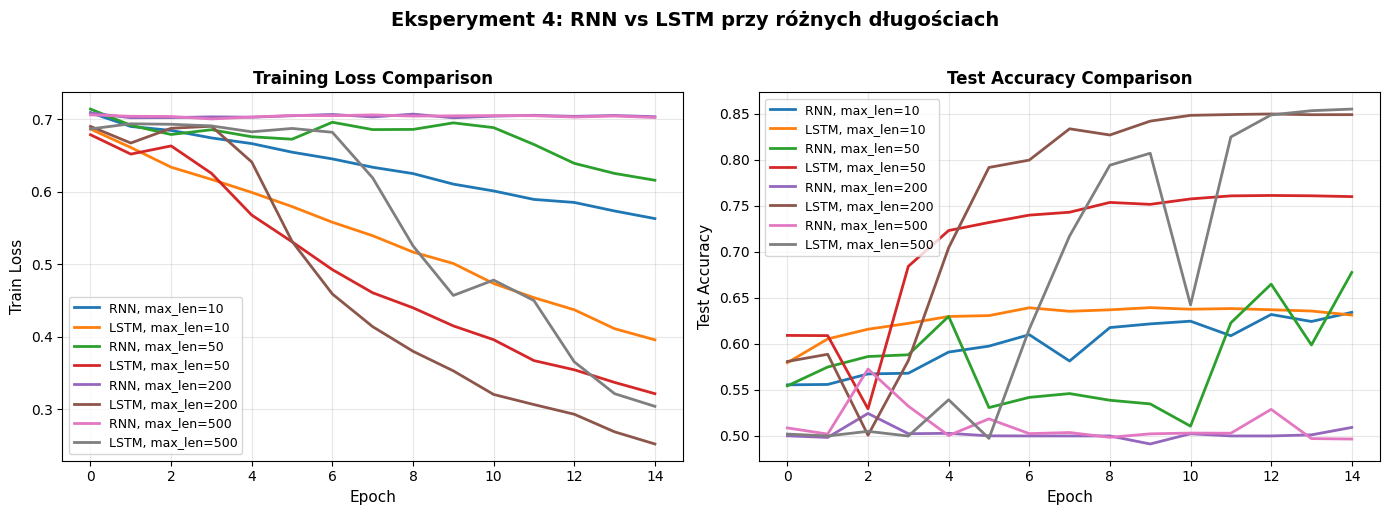


PODSUMOWANIE WYNIKÓW
Konfiguracja                                     Train Acc     Test Acc          Gap
------------------------------------------------------------------------------------------
RNN, max_len=10                                     0.7153       0.6342       0.0811
LSTM, max_len=10                                    0.8191       0.6313       0.1879
RNN, max_len=50                                     0.6730       0.6776      -0.0046
LSTM, max_len=50                                    0.8595       0.7599       0.0996
RNN, max_len=200                                    0.4990       0.5092      -0.0102
LSTM, max_len=200                                   0.8953       0.8489       0.0464
RNN, max_len=500                                    0.5073       0.4966       0.0106
LSTM, max_len=500                                   0.8703       0.8549       0.0154


In [14]:
print("\n=== Eksperyment 4: RNN vs LSTM przy różnych długościach ===")

results_comparison = []
test_lengths = [10, 50, 200, 500]

for max_len in test_lengths:
    for rnn_type in ['RNN', 'LSTM']:
        label = f'{rnn_type}, max_len={max_len}'
        print(f"\n--- Trenowanie {label} ---")
        
        train_loader, test_loader = create_data_loaders(
            train_data, train_labels, test_data, test_labels,
            max_len=max_len, batch_size=BATCH_SIZE, subset_size=TRAIN_SUBSET
        )
        
        model = SentimentRNN(
            vocab_size=VOCAB_SIZE,
            embed_dim=EMBED_DIM,
            hidden_dim=HIDDEN_DIM,
            output_dim=OUTPUT_DIM,
            rnn_type=rnn_type
        )
        
        history, trained_model = train_and_evaluate(
            model, train_loader, test_loader, epochs=EPOCHS, lr=LEARNING_RATE
        )
        
        results_comparison.append({
            'label': label,
            'history': history,
            'rnn_type': rnn_type,
            'max_len': max_len
        })

plot_comparison(results_comparison, "Eksperyment 4: RNN vs LSTM przy różnych długościach")
print_summary_table(results_comparison)

### Wnioski - Eksperyment 4:

**Zależność przewagi LSTM od długości sekwencji:**

- **Krótkie sekwencje (10/50 słów):** Różnica między RNN a LSTM jest niewielka - obie architektury radzą sobie z krótkimi zależnościami
  
- **Średnie sekwencje (200 słów):** LSTM zaczyna pokazywać przewagę - mechanizm bram pozwala na lepsze zachowanie informacji

- **Długie sekwencje (500 słów):** LSTM wyraźnie wygrywa - RNN cierpi na problem zanikającego gradientu

**Dlaczego LSTM jest lepszy dla długich sekwencji?**
- **Forget gate:** Decyduje, które informacje "zapomnieć"
- **Input gate:** Decyduje, które nowe informacje zachować
- **Output gate:** Decyduje, co zwrócić na wyjściu
- Te mechanizmy pozwalają na selektywne zachowywanie informacji na długich dystansach